In [1]:
!uv add ipympl

Resolved 87 packages in 0.50ms
Audited 86 packages in 0.76ms


In [2]:
%matplotlib widget
from icecream import ic

# sky_seg

In this Jupyter notebook, with assistance from Gemini Pro, I explore methods for classifying each pixel in an image as 'sky' or 'non-sky'.

Gemini wrote 2 python functions for me:
- **extract_sky_ai()**: classifies pixels as `sky` or `not sky` using the `segformer-b0` model
- **extract_sky_opencv()**: classifies pixels as `sky` or `not sky` using `opencv`

I edited both functions so that they return images instead of writing them to files.

## Gemini prompt
Write a python script which will identify every pixel in an image as sky or non-sky. 

## Response
To identify every pixel in an image as "sky" or "non-sky," you have two main paths in Python.

The traditional computer vision approach uses color thresholding (looking for blue pixels), which is fast and lightweight but fails on cloudy, night, or sunset skies. The modern machine learning approach uses semantic segmentation, which is highly robust and understands what a "sky" is regardless of color or lighting.

Here is a script for both methods so you can choose the one that best fits your needs.

## Method 1: The Modern AI Approach (Recommended)

This method uses a pre-trained machine learning model (SegFormer) from Hugging Face. It is incredibly accurate and will recognize night skies, gray clouds, and sunsets perfectly.

In [3]:
!uv add transformers torch torchvision pillow

Resolved 87 packages in 0.48ms
Audited 86 packages in 0.73ms


Loading AI model (this may take a while on the first run)...


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

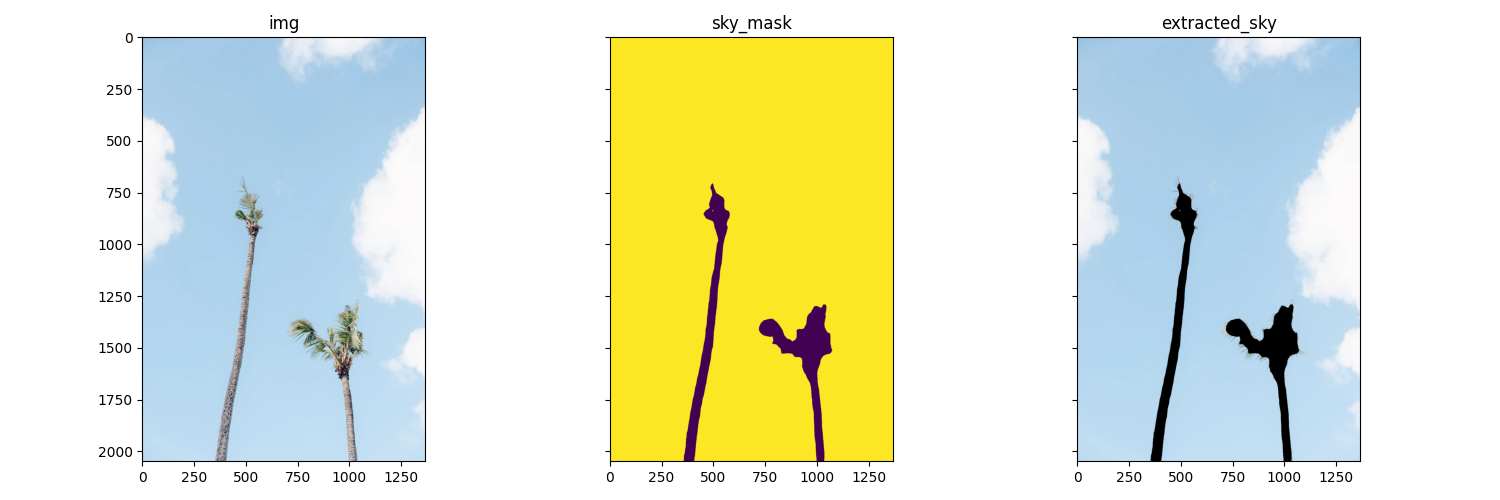

In [4]:
from transformers import pipeline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def extract_sky_ai(image_path, model="nvidia/segformer-b0-finetuned-ade-512-512"):
    """ 
    Segments every pixel in an image to `sky` or 'not sky` using a segformer model.
    Returns three images: the original image, the sky mask, and an image of all pixels 
    classed as `sky`
    """
    print("Loading AI model (this may take a while on the first run)...")
    # Initialize the pipeline with a model 
    # The default model is trained on the ADE20K dataset 
    # which specifically includes 'sky' as a label class).
    # The default model may be swapped for another onn
    # such as "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"
    segmenter = pipeline("image-segmentation", model=model)

    # Load the image
    try:
        img = Image.open(image_path)
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    results = segmenter(img)

    # Search the results for the 'sky' label
    sky_mask = None
    extracted_sky = None
    for result in results:
        if result['label'] == 'sky':
            sky_mask = result['mask']
            break

    if sky_mask:
        # Create a composite image showing only the sky
        img_array = np.array(img)
        mask_array = np.array(sky_mask)
        
        # Black out non-sky pixels
        img_array[mask_array == 0] = [0, 0, 0] 
        extracted_sky = Image.fromarray(img_array)
    else:
        print("No sky was detected in this image.")
        
    return img, sky_mask, extracted_sky

# Usage example

image_path = 'example_images/08hs-palms-03-zglw-superJumbo.webp'
img, sky_mask, extracted_sky = extract_sky_ai(image_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
axes[0].imshow(img)
axes[0].set_title('img')
axes[1].imshow(sky_mask)
axes[1].set_title('sky_mask')
axes[2].imshow(extracted_sky)
axes[2].set_title('extracted_sky')
plt.tight_layout() # Adjusts spacing automatically
plt.show()


## Method 2: The Lightweight OpenCV Approach

If you cannot use heavy AI models or only need to process clear, blue daytime skies, you can use OpenCV to filter the image by color mapping (HSV color space).

In [5]:
!uv add opencv-python numpy

Resolved 87 packages in 0.67ms
Audited 86 packages in 0.81ms


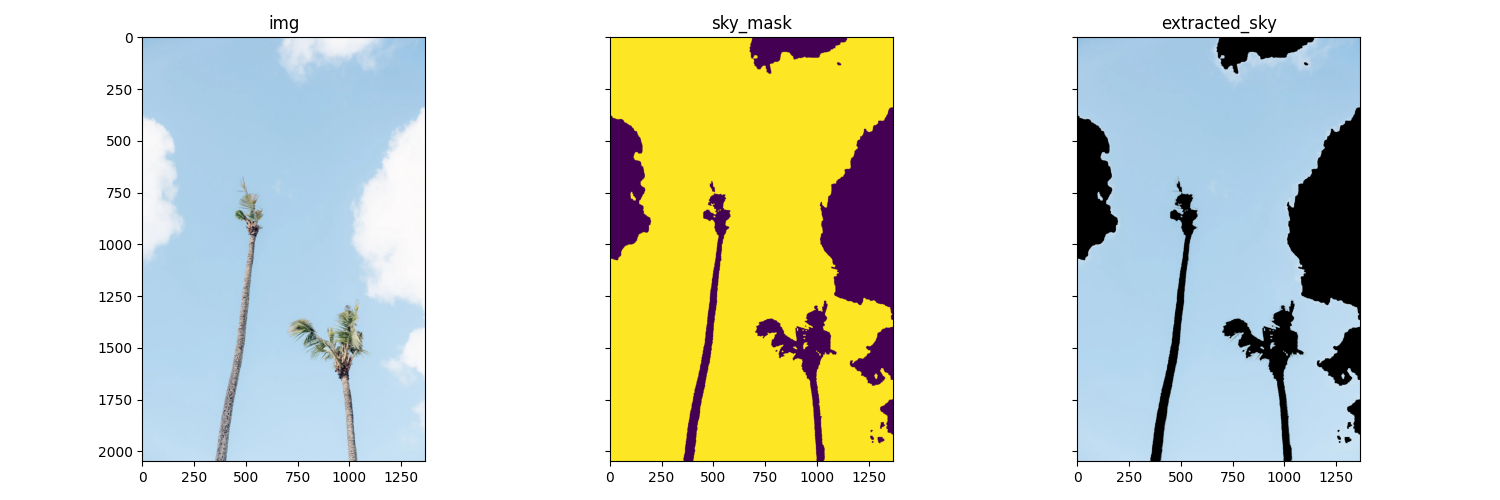

In [6]:
import cv2
import numpy as np

def extract_sky_opencv(image_path):
    """ 
    Segments every pixel in an image to `sky` or 'not sky` using a opencv.
    Returns three images: the original image, the sky mask, and an image of all pixels 
    classed as `sky`.
    """

    # Load the image using OpenCV
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not read image.")
        return

    # Convert the image from BGR (OpenCV default) to HSV (Hue, Saturation, Value)
    # HSV separates color (Hue) from lighting (Value), making thresholding much easier.
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define the HSV boundaries for a typical blue sky
    # Note: OpenCV Hue goes from 0-179, Saturation 0-255, Value 0-255
    lower_blue = np.array([85, 40, 50])   # Light/dark blues
    upper_blue = np.array([130, 255, 255]) # Cyan to deep blues

    # Create a binary mask where the blue colors fall within the range
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Clean up the mask using Morphological Operations
    # This removes small "dots" of blue (like a blue shirt) and fills in small gaps
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)  # Removes noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) # Fills holes
    sky_mask = mask

    extracted_sky = cv2.bitwise_and(img, img, mask=sky_mask)

    return img, sky_mask, extracted_sky

# Usage example

image_path = 'example_images/08hs-palms-03-zglw-superJumbo.webp'
img, sky_mask, extracted_sky = extract_sky_opencv(image_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
extracted_sky =cv2.cvtColor(extracted_sky, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
axes[0].imshow(img)
axes[0].set_title('img')
axes[1].imshow(sky_mask)
axes[1].set_title('sky_mask')
axes[2].imshow(extracted_sky)
axes[2].set_title('extracted_sky')
plt.tight_layout() # Adjusts spacing 
plt.show()


## Followup prompt
I am using the segformer model to classify pixels as sky or non-sky. Tips of some coconut fronds are being classified as "sky" in my test image. Are there parameters I can alter to prevent this misclassification?

## Gemini response
This is a classic challenge in semantic segmentation, particularly with thin, intricate structures like tree fronds, antennas, or wires. Because these thin objects are surrounded by the sky, the model's receptive field can be dominated by the background features, leading to boundary bleeding where the sky "swallows" the fine details. 

Depending on whether you are actively training the model or just running inference on a frozen one, here are the parameters and strategies you can adjust to fix this misclassification.

### 1. Inference & Post-Processing Adjustments (No Retraining Required)

If you are using pre-trained weights and cannot retrain, your options involve manipulating the model's outputs.

* **Adjust the Confidence Threshold:** If your model is outputting probabilities (e.g., using a Sigmoid or Softmax function before generating the final mask), the default threshold for classifying a pixel as "sky" is usually `0.5`. Try increasing this threshold (e.g., to `0.7` or `0.8`). This forces the model to be highly confident before it labels a pixel as sky, defaulting ambiguous pixels (like the frond tips) to non-sky.
* **Apply a Conditional Random Field (CRF):** CRFs are highly effective post-processing tools used to refine segmentation masks. They look at both the model's predicted probabilities and the original image's pixel intensities (colors and edges) to snap the segmentation mask strictly to the visual boundaries of the objects. 
* **Morphological Erosion:** If the sky mask is consistently bleeding over the fronds by a pixel or two, applying a gentle morphological erosion (using a library like OpenCV) to the predicted sky mask can shrink the edges back, revealing the fronds.

### 2. Training Parameters & Loss Functions (If Retraining)

If you have the ability to retrain or fine-tune the Segformer model, you can force it to pay more attention to these difficult boundary regions.

* **Switch to a Boundary-Aware Loss Function:** Standard Cross-Entropy loss often struggles with thin objects because they make up a tiny percentage of total pixels. 
    * **Focal Loss:** This dynamically scales the loss based on prediction confidence. It forces the model to focus heavily on "hard" pixels (like the misclassified frond tips) rather than the "easy" pixels (the big, obvious patches of sky).
    * **Dice Loss or Tversky Loss:** These optimize for the overlap between your prediction and the ground truth, which is much better for handling class imbalance (few frond pixels vs. many sky pixels). A common strategy is combining Cross-Entropy with Dice Loss.
* **Modify Image Resolution:** Segformer's hierarchical Transformer architecture is robust, but downsampling inherent in the encoder can still wash out high-frequency details. If your hardware allows, increase the input resolution during training and inference (e.g., $1024 \times 1024$ instead of $512 \times 512$). This gives the model more actual pixels to work with for those thin fronds.
* **Targeted Data Augmentation:** The model needs to see more examples of thin objects against the sky. Use random crops focusing on the tree canopies, or apply synthetic augmentations like sharpening and localized contrast adjustments to make the edges between the fronds and the sky "pop" more during training.

### 3. Segformer Architecture Parameters

* **Encoder Size:** Segformer comes in various sizes (MiT-B0 through MiT-B5). B0 is the fastest and lightest but has the lowest capacity for complex, fine-grained feature extraction. If you are using a smaller variant, scaling up to B2 or B3 might provide the parameter depth needed to distinguish the semantic difference between bright frond tips and the sky.

Are you currently in the training phase where you can adjust the loss functions and data, or are you strictly constrained to modifying the inference parameters of an already-trained model?

# Technical note

To allow running this notebook on Binder, I created a requirements.txt.
This will need to be rerun whenever I add a module using iv.
``` 
uv export --format requirements-txt > requirements.txt
```